# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **631 images**, equally divided into two categories:

- **With Helmet:** 311 images showing workers wearing helmets.
- **Without Helmet:** 320 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [ ]:
#Code to detect presence of GPU
import torch
import tensorflow as tf

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU is available.")
    print(f"Number of GPUs available: {torch.cuda.device_count()}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    DEVICE_NAME = 'GPU'
    print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
    print(tf.__version__)
else:
    device = torch.device("cpu")
    print("GPU is not available, using CPU.")
    DEVICE_NAME = 'CPU'

print(f"Device: {device}")

GPU is available.
Number of GPUs available: 1
GPU Name: Tesla T4
Num GPUs Available: 1
2.18.0
Device: cuda


In [ ]:
# Library error avoidance
# Uninstall some current library versions
#!pip uninstall -y numpy numba nvidia-cublas-cu12 nvidia-cuda-cupti-cu12 \
#nvidia-cuda-nvrtc-cu12 nvidia-cuda-runtime-cu12 nvidia-cudnn-cu12 \
#nvidia-cufft-cu12 nvidia-curand-cu12 nvidia-cusolver-cu12 nvidia-cusparse-cu12 \
#nvidia-nvjitlink-cu12

# Install the required library versions
#!pip install "numpy==2" "numba==0.60.0" "nvidia-cublas-cu12==12.4.5.8" \
#"nvidia-cuda-cupti-cu12==12.4.127" "nvidia-cuda-nvrtc-cu12==12.4.127" \
#"nvidia-cuda-runtime-cu12==12.4.127"  "nvidia-cudnn-cu12==9.1.0.70" \
#"nvidia-cufft-cu12==11.2.1.3" "nvidia-curand-cu12==10.3.5.147" \
#"nvidia-cusolver-cu12==11.6.1.9" "nvidia-cusparse-cu12==12.3.1.170" \
#"nvidia-nvjitlink-cu12==12.4.127" --force-reinstall --no-cache-dir -q

# List versions of libraries installed
%pip list | grep -iE '^(numpy|numba|nvidia|cuda|tensorflow)'| awk '{print $1, $2}'


cuda-python 12.6.2.post1
numba 0.60.0
numba-cuda 0.2.0
numpy 2.0.2
nvidia-cublas-cu12 12.5.3.2
nvidia-cuda-cupti-cu12 12.5.82
nvidia-cuda-nvcc-cu12 12.5.82
nvidia-cuda-nvrtc-cu12 12.5.82
nvidia-cuda-runtime-cu12 12.5.82
nvidia-cudnn-cu12 9.3.0.75
nvidia-cufft-cu12 11.2.3.61
nvidia-curand-cu12 10.3.6.82
nvidia-cusolver-cu12 11.6.3.83
nvidia-cusparse-cu12 12.5.1.3
nvidia-cusparselt-cu12 0.6.2
nvidia-ml-py 12.575.51
nvidia-nccl-cu12 2.21.5
nvidia-nvcomp-cu12 4.2.0.11
nvidia-nvjitlink-cu12 12.5.82
nvidia-nvtx-cu12 12.4.127
tensorflow 2.18.0
tensorflow-datasets 4.9.9
tensorflow_decision_forests 1.11.0
tensorflow-hub 0.16.1
tensorflow-io-gcs-filesystem 0.37.1
tensorflow-metadata 1.17.1
tensorflow-probability 0.25.0
tensorflow-text 2.18.1


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd                                                                              # Importing pandas to read CSV files
import seaborn as sns
import matplotlib.image as mpimg
import matplotlib.pyplot as plt                                                                  # Importing matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
RANDOM_SEED = 812
tf.keras.utils.set_random_seed(RANDOM_SEED)

# **Data Overview**


##Loading the data

In [ ]:
#Specific to my environment/folder structure
from google.colab import drive
drive.mount('/content/drive/',force_remount = True)

#Specific to my environment/folder structure. Define the folder/directory path
FOLDER_PATH = '/content/drive/MyDrive/Colab_Notebooks/HelmNet_Project/'

Mounted at /content/drive/


In [ ]:
# Load the image file of the dataset
images = np.load(FOLDER_PATH+'images_proj.npy')

# Load the labels file of the dataset
labels = pd.read_csv(FOLDER_PATH+'Labels_proj.csv')

In [ ]:
print(images.shape)
print(labels.shape)

(631, 200, 200, 3)
(631, 1)


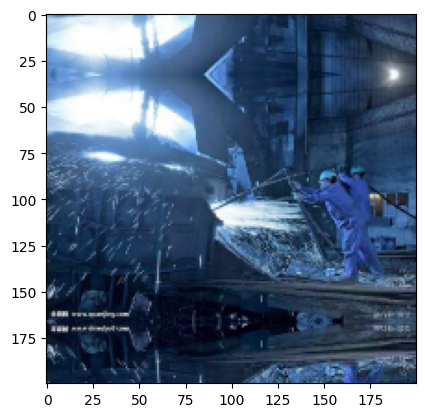

In [ ]:
plt.imshow(images[5]);

* We have 631 images and corresponding labels.
* It is visible that the images are being displayed in the BGR format. We will have to convert them.

# **Exploratory Data Analysis**

In [ ]:
rgb_images = []
# Converting the images from BGR to RGB using cvtColor function of OpenCV
rgb_images = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in images]

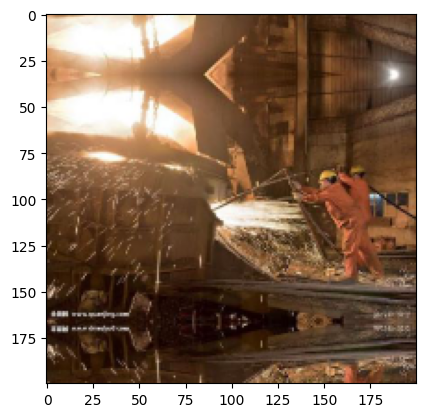

In [ ]:
plt.imshow(rgb_images[5]);

###Plot random images from each of the classes and print their corresponding labels.

In [ ]:
def display_random_images(images, labels):

    # Define the mapping from integer label to string name
    label_map = {1: "With Helmet", 0: "Without Helmet"}

    # Define grid dimensions
    rows = 3
    cols = 4

    # Create the figure
    fig = plt.figure(figsize=(12, 9))

    for i in range(rows * cols):
        # Select a random image from the dataset
        random_index = np.random.randint(0, len(images))

        # Get the image and its corresponding label
        image = images[random_index]
        # Access the label from the 'Label' column of the DataFrame using the integer index
        label = labels['Label'][random_index]

        # Get the string title from the label map
        title = label_map.get(label, "Unknown Label")

        # Add a subplot to the figure
        ax = fig.add_subplot(rows, cols, i + 1)
        ax.imshow(image)
        ax.set_title(title, fontsize=12)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

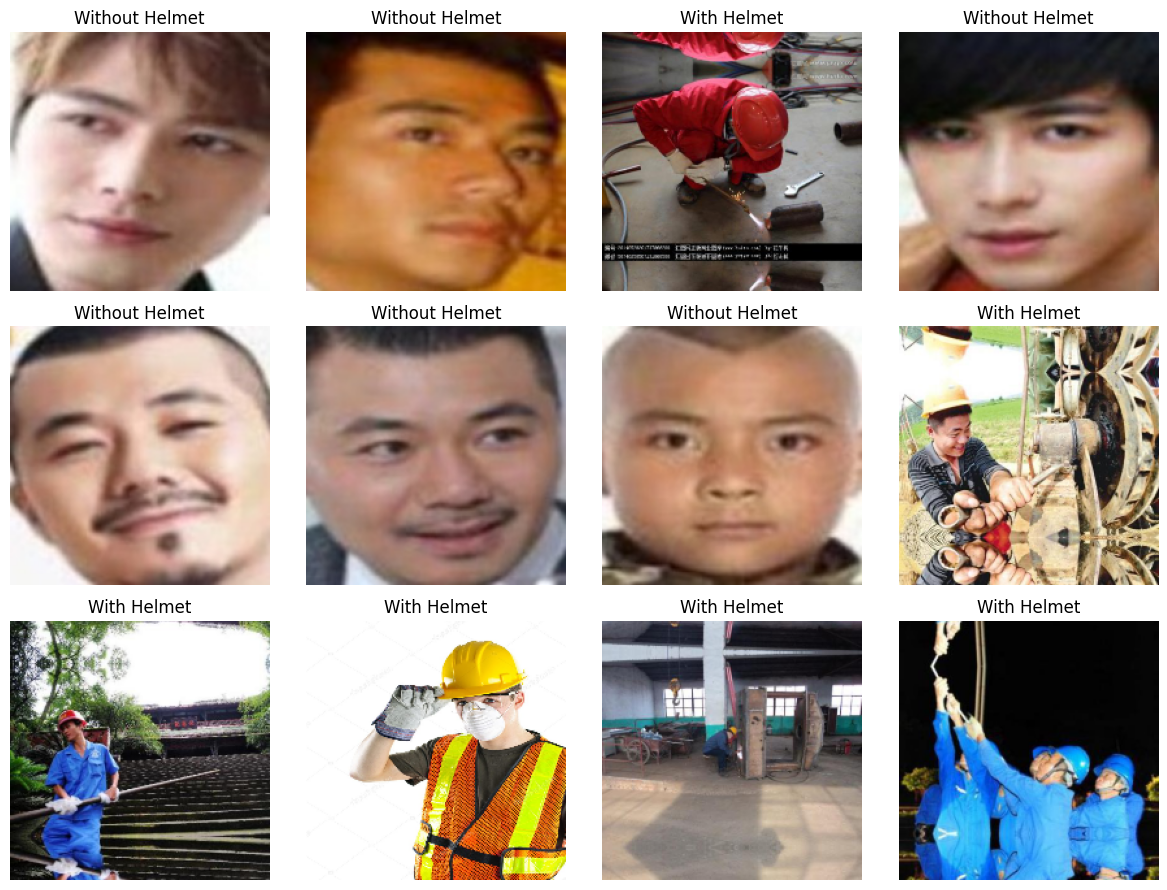

In [ ]:
display_random_images(rgb_images, labels)

## Checking for class imbalance


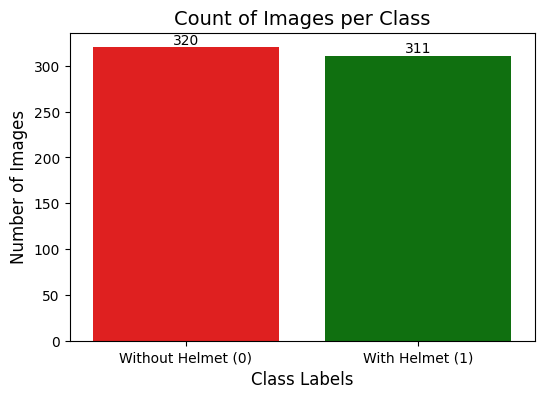

In [ ]:
# Set the style for the plot for better aesthetics
#sns.set_style("whitegrid")

# Create a count plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=labels.iloc[:, 0], palette=['red', 'green'])

# Add exact counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, )

# Add labels
plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Count of Images per Class", fontsize=14)
plt.xticks(ticks=[0, 1], labels=["Without Helmet (0)", "With Helmet (1)"])  # Rename x-axis labels

# Show plot
plt.show()

* The dataset seems to be balanced within the two categories - "Without Helmet" and "With Helmet".

# **Data Preprocessing**

## Converting images to grayscale

In [ ]:
# Function to plot the original and processed images side by side
def grid_plot(img1,img2,gray=False):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img1)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    if gray:
      axes[1].imshow(img2,cmap='gray')
    else:
      axes[1].imshow(img2)
    axes[1].set_title('Processed Image')
    axes[1].axis('off')

    plt.show()

In [ ]:
gray_images = []

#Convert the all "rgb_images" to grayscale using cvtColor and store in gray_images
for i in range(len(rgb_images)):
  gray_images.append(cv2.cvtColor(rgb_images[i], cv2.COLOR_RGB2GRAY))

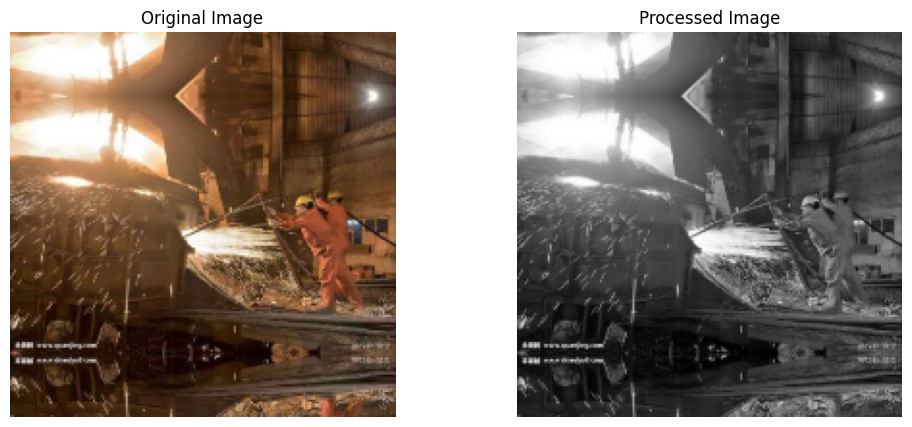

In [ ]:
# choosing an image
n = 5
# plotting the original and preprocessed image
grid_plot(rgb_images[n],gray_images[n],gray=True)

* The RGB component has been removed.
* Usage of grayscale may remove the features required for identification of an helmet and hence we will continue using the RGB format images.
* This was a good exploratory section.

### Splitting the dataset



* There are fewer images in our dataset and hence we have split the data into:
  * Training = 80%
  * Validation = 10%
  * Testing = 10%

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(np.array(rgb_images),labels , test_size=0.2, random_state=RANDOM_SEED,stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp , test_size=0.5, random_state=RANDOM_SEED,stratify=y_temp)

In [ ]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(504, 200, 200, 3) (504, 1)
(63, 200, 200, 3) (63, 1)
(64, 200, 200, 3) (64, 1)


* The "lables" data has just 0 and 1s and hence we do not need to encode it

### Data Normalization

In [ ]:
# Image values range from 0 to 255 and hence we will normalize it
# Normalizing the image pixels
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

# **Model Building**

##Model Evaluation Criterion

## Utility Functions

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [ ]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

In [ ]:
def extract_metrics(history):
    # --- 1. Extract Data ---
    # Use .get with a default of an empty list to prevent errors if a key is missing
    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])

    # Ensure there's data to analyze
    if not val_acc or not val_loss:
        return {"Error": "Missing validation metrics in history."}

    num_epochs = len(val_acc)

    # --- 2. Overfitting Analysis ---
    # Find the epoch with the best (lowest) validation loss
    best_epoch = np.argmin(val_loss)
    min_val_loss = val_loss[best_epoch]

    overfitting_desc = "No clear sign of overfitting."
    # Check if the model's performance on validation data has started to degrade
    if val_loss[-1] > min_val_loss:
        overfitting_desc = f"Possible overfitting after epoch {best_epoch + 1}."
    # Also check if there's a significant gap between training and validation accuracy
    elif (acc[-1] - val_acc[-1]) > 0.15: # 15% gap is a strong indicator
        overfitting_desc = "Significant gap between training and validation accuracy."

    # --- 3. Stability Analysis (Focus on the end of training) ---
    stability_window = 5 # Analyze the last 5 epochs
    stability_desc = "Not enough epochs to assess stability."

    if num_epochs >= stability_window:
        # Calculate the standard deviation of validation accuracy in the final epochs
        last_n_val_acc = val_acc[-stability_window:]
        std_dev = np.std(last_n_val_acc)

        if std_dev < 0.01: # Less than 1% fluctuation
            stability_desc = "Stable"
        elif std_dev < 0.03: # 1-3% fluctuation
            stability_desc = "Slightly Unstable"
        else: # More than 3% fluctuation
            stability_desc = "Unstable"

    # --- 4. Compile and Return Results ---
    return {
        'Final Training Accuracy': f"{acc[-1] * 100:.2f}%",
        'Final Validation Accuracy': f"{val_acc[-1] * 100:.2f}%",
        'Final Training Loss': f"{loss[-1]:.4f}",
        'Best Validation Loss': f"{min_val_loss:.4f} (at Epoch {best_epoch + 1})",
        'Overfitting Status': overfitting_desc,
        'Validation Accuracy Stability': stability_desc
    }

##Model 1: Simple Convolutional Neural Network (CNN)

### a. CNN

In [ ]:
# Epochs
EPOCHS = 30
# Batch size
BATCH_SIZE = 128

In [ ]:
#Build a CNN with 3 convolution layers and 2 pooling layers
model_cnn = Sequential()

#Feature Extraction Layers
#-------------------------

# 1st Conv + Pooling
model_cnn.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(200,200,3)))
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))

# 2nd Conv + Pooling
model_cnn.add(Conv2D(64, (3, 3), activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))

# 3rd Conv layer (no pooling)
model_cnn.add(Conv2D(128, (3, 3), activation='relu'))


# Fully Connected Classification Layer
#-------------------------------------
# Flatten and Dense layers
model_cnn.add(Flatten())
model_cnn.add(Dense(64, activation='relu'))

# Output layer for binary classification
model_cnn.add(Dense(1, activation='sigmoid'))  # Sigmoid for binary classification


# Using Adam Optimizer
opt = Adam(learning_rate=0.001)

# Compile model
model_cnn.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy','precision'])

# Generating the summary of the model
model_cnn.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 98, 98, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 47, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 282752)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │    18,096,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,189,505 (69.39 MB)

 Trainable params: 18,189,505 (69.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_1 = model_cnn.fit(
            X_train_normalized, y_train,
            epochs=EPOCHS,
            validation_data=(X_val_normalized,y_val),
            shuffle=True,
            batch_size=BATCH_SIZE,
            verbose=2
)

Epoch 1/30
4/4 - 12s - 3s/step - accuracy: 0.5258 - loss: 3.1247 - precision: 0.5178 - val_accuracy: 0.8095 - val_loss: 0.5410 - val_precision: 1.0000
Epoch 2/30
4/4 - 1s - 239ms/step - accuracy: 0.5714 - loss: 0.8389 - precision: 0.5377 - val_accuracy: 0.4921 - val_loss: 0.4730 - val_precision: 0.4921
Epoch 3/30
4/4 - 1s - 309ms/step - accuracy: 0.7639 - loss: 0.4166 - precision: 0.6797 - val_accuracy: 1.0000 - val_loss: 0.2309 - val_precision: 1.0000
Epoch 4/30
4/4 - 1s - 340ms/step - accuracy: 0.9643 - loss: 0.1854 - precision: 0.9792 - val_accuracy: 1.0000 - val_loss: 0.0120 - val_precision: 1.0000
Epoch 5/30
4/4 - 1s - 249ms/step - accuracy: 0.9683 - loss: 0.1001 - precision: 0.9754 - val_accuracy: 0.9841 - val_loss: 0.0169 - val_precision: 1.0000
Epoch 6/30
4/4 - 1s - 300ms/step - accuracy: 0.9663 - loss: 0.0948 - precision: 0.9529 - val_accuracy: 0.9841 - val_loss: 0.0522 - val_precision: 1.0000
Epoch 7/30
4/4 - 1s - 285ms/step - accuracy: 0.9643 - loss: 0.0759 - precision: 1.00

### b. CNN With Dropout = 0.5, Early Stopping

In [ ]:
#Build a CNN with 3 convolution layers and 2 pooling layers
model_cnn_does = Sequential()

#Feature Extraction Layers
#-------------------------

# 1st Conv + Pooling
model_cnn_does.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(200,200,3)))
model_cnn_does.add(MaxPooling2D(pool_size=(2, 2)))

# 2nd Conv + Pooling
model_cnn_does.add(Conv2D(64, (3, 3), activation='relu'))
model_cnn_does.add(MaxPooling2D(pool_size=(2, 2)))

# 3rd Conv layer (no pooling)
model_cnn_does.add(Conv2D(128, (3, 3), activation='relu'))


# Fully Connected Classification Layer
#-------------------------------------
# Flatten and Dense layers
model_cnn_does.add(Flatten())
model_cnn_does.add(Dense(64, activation='relu'))
model_cnn_does.add(Dropout(0.5))  # Helps prevent overfitting

# Output layer for binary classification
model_cnn_does.add(Dense(1, activation='sigmoid'))  # Sigmoid for binary classification

# Using Adam Optimizer
opt = Adam(learning_rate=0.001)

# Compile model
model_cnn_does.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy','precision'])

# Generating the summary of the model
model_cnn_does.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 98, 98, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 47, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 282752)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │    18,096,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,189,505 (69.39 MB)

 Trainable params: 18,189,505 (69.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
history_2 = model_cnn_does.fit(
            X_train_normalized, y_train,
            epochs=EPOCHS,
            validation_data=(X_val_normalized,y_val),
            shuffle=True,
            batch_size=BATCH_SIZE,
            callbacks=[early_stop],
            verbose=2
)

Epoch 1/30
4/4 - 8s - 2s/step - accuracy: 0.5516 - loss: 3.2836 - precision: 0.5423 - val_accuracy: 0.9524 - val_loss: 0.4807 - val_precision: 0.9375
Epoch 2/30
4/4 - 5s - 1s/step - accuracy: 0.5813 - loss: 0.7039 - precision: 0.5433 - val_accuracy: 0.9524 - val_loss: 0.4185 - val_precision: 0.9118
Epoch 3/30
4/4 - 1s - 302ms/step - accuracy: 0.8671 - loss: 0.3780 - precision: 0.7891 - val_accuracy: 1.0000 - val_loss: 0.1817 - val_precision: 1.0000
Epoch 4/30
4/4 - 1s - 199ms/step - accuracy: 0.9583 - loss: 0.1917 - precision: 0.9671 - val_accuracy: 1.0000 - val_loss: 0.0163 - val_precision: 1.0000
Epoch 5/30
4/4 - 1s - 189ms/step - accuracy: 0.9524 - loss: 0.1644 - precision: 0.9444 - val_accuracy: 0.9841 - val_loss: 0.0496 - val_precision: 1.0000
Epoch 6/30
4/4 - 1s - 202ms/step - accuracy: 0.9821 - loss: 0.0762 - precision: 0.9918 - val_accuracy: 1.0000 - val_loss: 0.0123 - val_precision: 1.0000
Epoch 7/30
4/4 - 1s - 310ms/step - accuracy: 0.9901 - loss: 0.0540 - precision: 0.9841 -

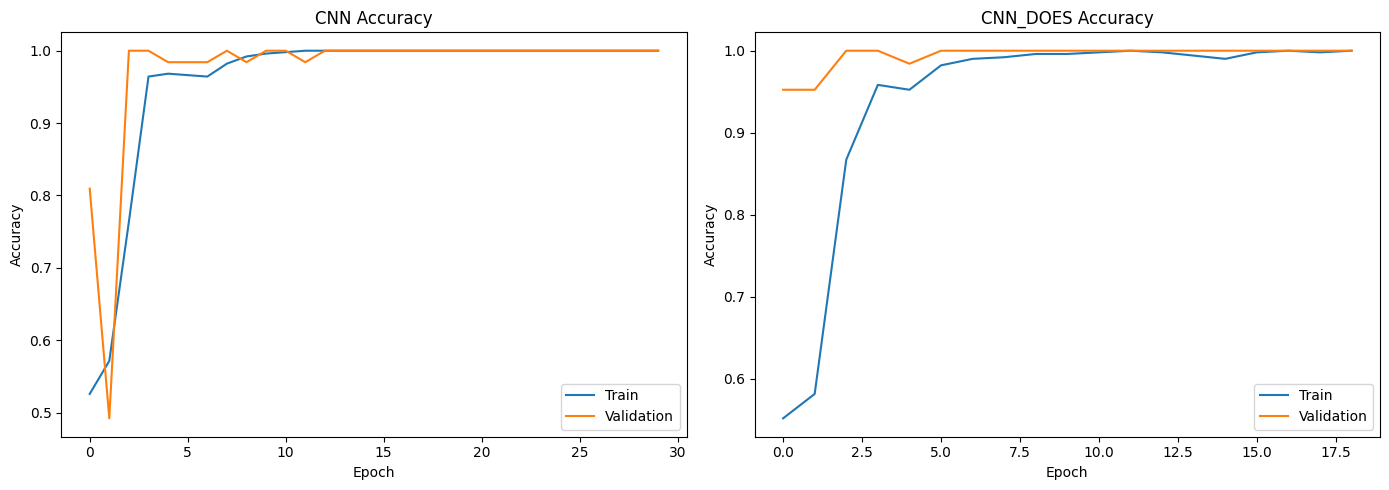

In [ ]:
# Create subplots: 1 row, 2 columns
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot for CNN
axs[0].plot(history_1.history['accuracy'], label='Train')
axs[0].plot(history_1.history['val_accuracy'], label='Validation')
axs[0].set_title('CNN Accuracy')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].legend(loc='lower right')

# Plot for CNN with Dropout and Early stopping
axs[1].plot(history_2.history['accuracy'], label='Train')
axs[1].plot(history_2.history['val_accuracy'], label='Validation')
axs[1].set_title('CNN_DOES Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [ ]:
# Extract from history objects
metrics_cnn = extract_metrics(history_1)
metrics_cnn_does = extract_metrics(history_2)

# Construct DataFrame
comparison_df = pd.DataFrame({
    'Metric': metrics_cnn.keys(),
    'CNN': metrics_cnn.values(),
    'CNN_DOES': metrics_cnn_does.values()
})

# Display
comparison_df

,Metric,CNN,CNN_DOES
0,Final Training Accuracy,100.00%,100.00%
1,Final Validation Accuracy,100.00%,100.00%
2,Final Training Loss,0.0000,0.0053
3,Best Validation Loss,0.0000 (at Epoch 30),0.0001 (at Epoch 14)
4,Overfitting Status,No clear sign of overfitting.,Possible overfitting after epoch 14.
5,Validation Accuracy Stability,Stable,Stable


### Observations
* Plain CNN:
  * Shows fluctuation in validation accuracy/loss around epochs 4 and 9
  * This could be due to overfitting
  * Final accuracy is lower and Validation loss is higher than CNN_DOES
* CNN with Dropout and Early stopping (CNN_DOES):
  * Has better generalization. Despite the higher initial loss, it improves and maintains consistent performance on Validation data.
  * Final Validation Loss is almost negligible.
  * Dropout effectively regularized the dense layer.
  * The baseline model (Plain CNN) serves as a control, but adding dropouts and early stopping helps build a better model.
* Based on our observations we can choose CNN_DOES for further performance evaluation.
* Small dataset might also be playing a role here (631 images)
* **We will use dropouts, early stopping and batch normalization going forward**

### Performance

In [ ]:
model_cnn_does_train_perf = model_performance_classification(model_cnn_does, X_train_normalized,y_train)

print("Train performance metrics")
print(model_cnn_does_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


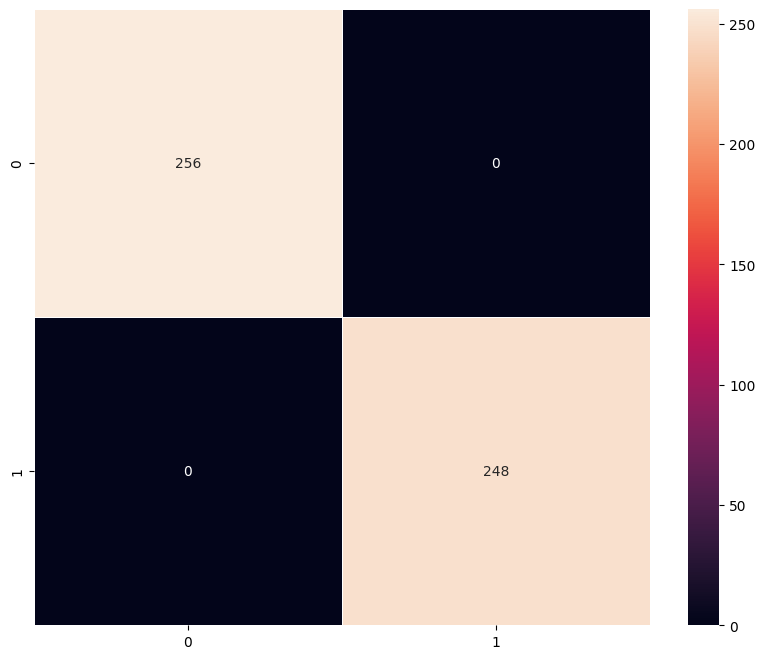

In [ ]:
plot_confusion_matrix(model_cnn_does,X_train_normalized,y_train)

In [ ]:
model_cnn_does_valid_perf = model_performance_classification(model_cnn_does, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_cnn_does_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


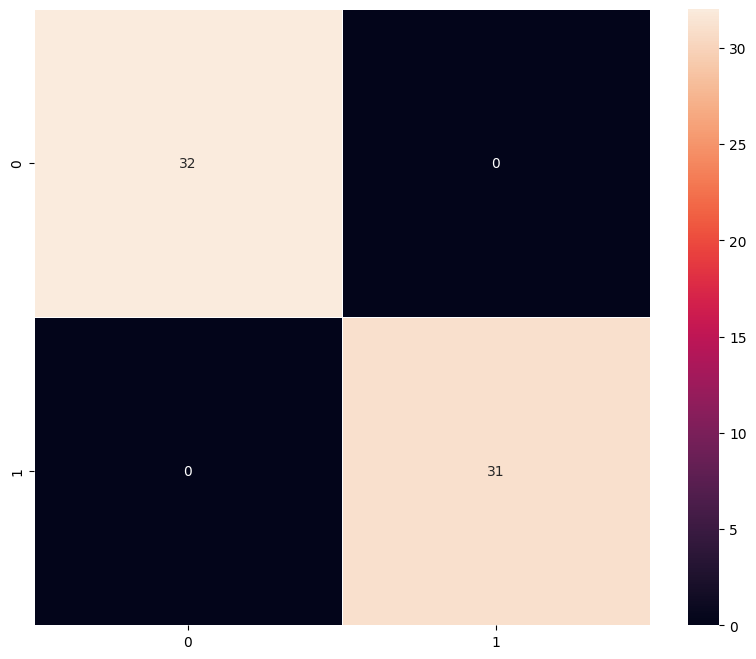

In [ ]:
plot_confusion_matrix(model_cnn_does,X_val_normalized,y_val)

### Vizualizing the predictions

In [ ]:
def predict_and_show(index, model, X_val, X_val_normalized, y_val, input_shape=(200, 200, 3)):

  LABEL_MAP = {
    0: "Without Helmet",
    1: "With Helmet"
  }

  # Show image
  plt.figure(figsize=(2, 2))
  plt.imshow(X_val[index])
  plt.axis('off')
  plt.show()

  # Predict
  prediction = model.predict(X_val_normalized[index].reshape(1, *input_shape))
  predicted_label = int(prediction[0][0] > 0.5)

  # True label extraction
  # Correctly access the label from the DataFrame using iloc for integer indexing
  true_label = y_val.iloc[index]['Label']

  # Use the LABEL_MAP dictionary to get the human-readable text for both labels
  predicted_label_text = LABEL_MAP[predicted_label]
  true_label_text = LABEL_MAP[true_label]

  # Output
  print(f'Predicted Label: {predicted_label_text}')
  print(f'True Label: {true_label_text}')

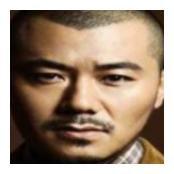

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
Predicted Label: Without Helmet
True Label: Without Helmet


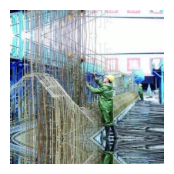

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Label: With Helmet
True Label: With Helmet


In [ ]:
# For index 12
predict_and_show(12, model_cnn_does, X_val, X_val_normalized, y_val)

# For index 33
predict_and_show(33, model_cnn_does, X_val, X_val_normalized, y_val)

* Both the baseline CNN and the regularized CNN_DOES achieved 100% accuracy on the validation set. This perfect score is a major red flag, suggesting the validation data is too small and not challenging enough to be a realistic test of the model's ability to generalize.

* Baseline Model Shows Instability: Although it eventually reached 100% accuracy, the initial model_cnn showed volatile performance in the early epochs. This instability is a symptom of a model starting to overfit; it is memorizing the training data rather than learning robust, general features.

* The improved model, CNN_DOES, includes Dropout and Early Stopping, which are essential techniques for preventing overfitting. Even though the dataset's simplicity masks their full impact, we will select CNN_DOES for further evaluation - It is theoretically the more reliable and trustworthy model of the two.

## Model 2: (VGG-16 (Base))

In [ ]:
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(200,200,3))
vgg_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Freezing the layers of the VGG model
for layer in vgg_model.layers:
    layer.trainable = False

In [ ]:
model_vgg_base = Sequential()

#Adding the convolutional part of the VGG16 model from above
model_vgg_base.add(vgg_model)

#Flattening the output of the VGG16 model because it is from a convolutional layer
model_vgg_base.add(Flatten())

# Dropout with 50% rate (tune as needed)
model_vgg_base.add(Dropout(0.5))

#Adding a dense output layer
model_vgg_base.add(Dense(1, activation='sigmoid'))

In [ ]:
opt=Adam(learning_rate=0.001)

#Compile model
model_vgg_base.compile(optimizer=opt, loss=keras.losses.BinaryCrossentropy(), metrics=['accuracy','precision'])

#Model Summary
model_vgg_base.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │        18,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,121 (56.20 MB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
train_datagen = ImageDataGenerator()

In [ ]:
history_3 = model_vgg_base.fit(train_datagen.flow(X_train_normalized,y_train,
                                      batch_size=BATCH_SIZE,
                                      seed=RANDOM_SEED,
                                      shuffle=False),
                    epochs=EPOCHS,
                    steps_per_epoch=X_train_normalized.shape[0] // BATCH_SIZE,
                    validation_data=(X_val_normalized,y_val),
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.7096 - loss: 0.5343 - precision: 0.7293 - val_accuracy: 1.0000 - val_loss: 0.1844 - val_precision: 1.0000
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 351ms/step - accuracy: 0.9609 - loss: 0.1950 - precision: 0.9242 - val_accuracy: 1.0000 - val_loss: 0.1012 - val_precision: 1.0000
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 690ms/step - accuracy: 0.9934 - loss: 0.0995 - precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0334 - val_precision: 1.0000
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - accuracy: 1.0000 - loss: 0.0355 - precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0256 - val_precision: 1.0000
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 676ms/step - accuracy: 0.9915 - loss: 0.0311 - precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0105 - val_precision: 1.0000
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - accuracy: 0.9922 - loss: 0.0274 - precision: 0.9831 - val_accuracy: 1.0000 - val_loss: 0.0083 - val_p

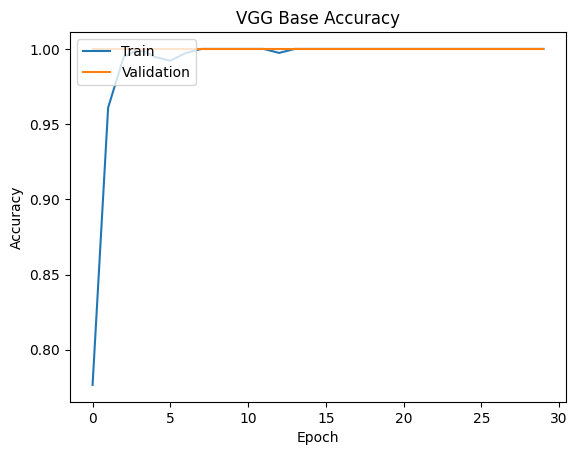

In [ ]:
plt.plot(history_3.history['accuracy'])
plt.plot(history_3.history['val_accuracy'])
plt.title('VGG Base Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_vgg_base_train_perf = model_performance_classification(model_vgg_base,X_train_normalized,y_train)

print("Train performance metrics")
print(model_vgg_base_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step


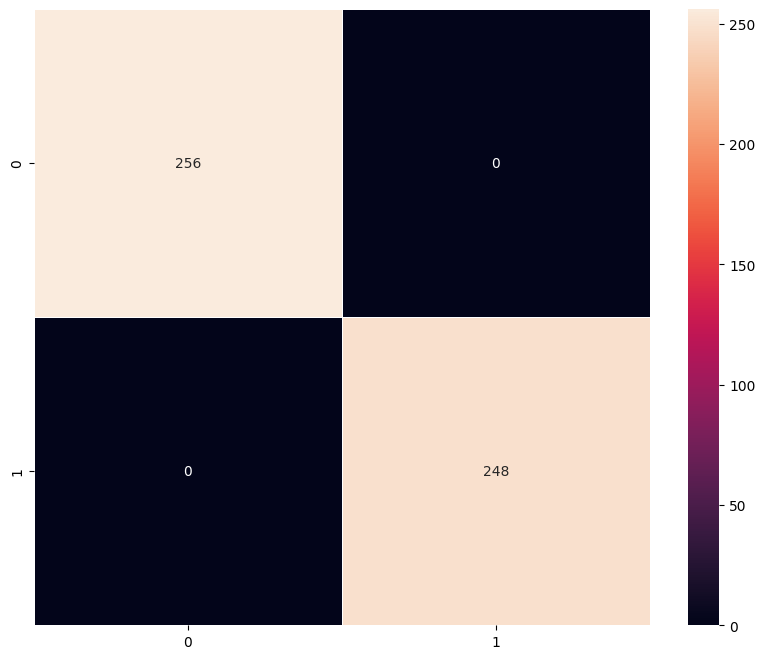

In [ ]:
plot_confusion_matrix(model_vgg_base,X_train_normalized,y_train)

In [ ]:
model_vgg_base_valid_perf = model_performance_classification(model_vgg_base, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_vgg_base_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 419ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


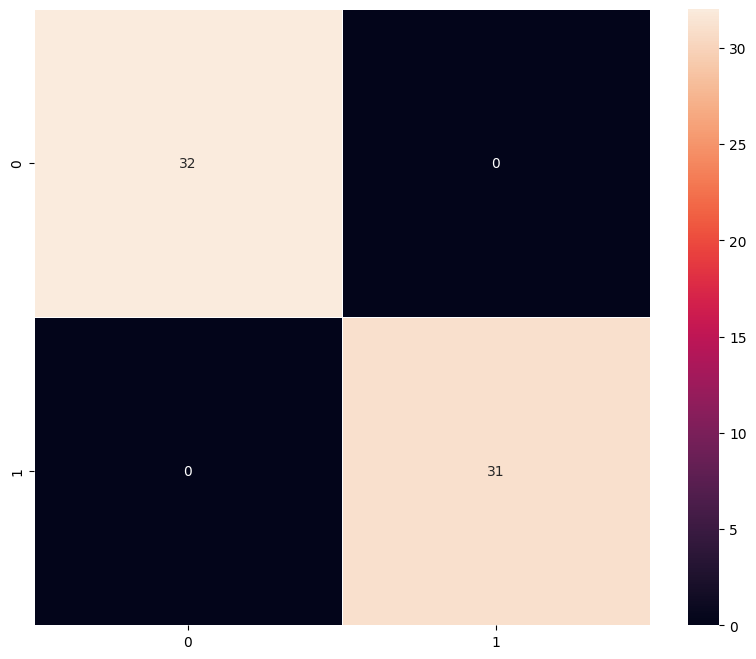

In [ ]:
plot_confusion_matrix(model_vgg_base,X_val_normalized,y_val)

### Visualizing the prediction:

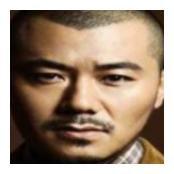

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
Predicted Label: Without Helmet
True Label: Without Helmet


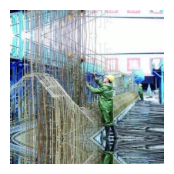

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Label: With Helmet
True Label: With Helmet


In [ ]:
# For index 12
predict_and_show(12, model_vgg_base, X_val, X_val_normalized, y_val)

# For index 33
predict_and_show(33, model_vgg_base, X_val, X_val_normalized, y_val)

In [ ]:
# Extract from history objects
metrics_vgg_base = extract_metrics(history_3)

# Construct DataFrame
comparison_df = pd.DataFrame({
    'Metric': metrics_cnn.keys(),
    'CNN': metrics_cnn.values(),
    'CNN_DOES': metrics_cnn_does.values(),
    'VGG_Base': metrics_vgg_base.values()
})

# Display
comparison_df

,Metric,CNN,CNN_DOES,VGG_Base
0,Final Training Accuracy,100.00%,100.00%,100.00%
1,Final Validation Accuracy,100.00%,100.00%,100.00%
2,Final Training Loss,0.0000,0.0053,0.0006
3,Best Validation Loss,0.0000 (at Epoch 30),0.0001 (at Epoch 14),0.0010 (at Epoch 30)
4,Overfitting Status,No clear sign of overfitting.,Possible overfitting after epoch 14.,No clear sign of overfitting.
5,Validation Accuracy Stability,Stable,Stable,Stable


* Model 2 (VGG 16 Base) achieved a perfect 100% validation accuracy in the very first epoch. This demonstrates the power of transfer learning and reinforces that the validation dataset is not challenging enough to be a meaningful benchmark.

* This model shows that leveraging a pre-trained network like VGG16 is effective than a custom CNN for this task.

* The features extracted by VGG16 are so good that the model could solve the problem almost instantly, even with a very simple classification.

* The training and validation accuracy curves rise to 100% together and stay locked there. This indicates that, for this simple dataset, the model generalizes perfectly from the training to the validation set, with no signs of overfitting.

## Model 3: (VGG-16 (Base + FFNN))

- We will directly use the convolutional and pooling layers (VGG-16) and freeze their weights i.e. no training will be done on them.
- For classification, we will add a Flatten layer and a Feed Forward Neural Network.


In [ ]:
model_vgg_base_ffnn = Sequential()

# Adding the convolutional part of VGG16
model_vgg_base_ffnn.add(vgg_model)

# Flattening the output of the VGG16 model
model_vgg_base_ffnn.add(Flatten())

# First dense layer + Dropout
model_vgg_base_ffnn.add(Dense(256, activation='relu'))
model_vgg_base_ffnn.add(BatchNormalization())
model_vgg_base_ffnn.add(Dropout(0.5))  # helps regularize the largest dense layer

# Second dense layer + Dropout
model_vgg_base_ffnn.add(Dense(128, activation='relu'))
model_vgg_base_ffnn.add(BatchNormalization())
model_vgg_base_ffnn.add(Dropout(0.3))  # slightly lower rate here

# Third dense layer + Dropout
model_vgg_base_ffnn.add(Dense(64, activation='relu'))
model_vgg_base_ffnn.add(BatchNormalization())
model_vgg_base_ffnn.add(Dropout(0.3))

# Fourth dense layer (no dropout since it's small)
model_vgg_base_ffnn.add(Dense(32, activation='relu'))

# Output layer
model_vgg_base_ffnn.add(Dense(1, activation='sigmoid'))

In [ ]:
opt=Adam(learning_rate=0.001)

#Compile model
model_vgg_base_ffnn.compile(optimizer=opt, loss=keras.losses.BinaryCrossentropy(), metrics=['accuracy','precision'])

#Model Summary
model_vgg_base_ffnn.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,478,593 (74.30 MB)

 Trainable params: 4,763,009 (18.17 MB)

 Non-trainable params: 14,715,584 (56.14 MB)

In [ ]:
history_4 = model_vgg_base_ffnn.fit(train_datagen.flow(X_train_normalized,y_train,
                                      batch_size=BATCH_SIZE,
                                      seed=RANDOM_SEED,
                                      shuffle=False),
                    epochs=EPOCHS,
                    steps_per_epoch=X_train_normalized.shape[0] // BATCH_SIZE,
                    validation_data=(X_val_normalized,y_val),
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.5818 - loss: 0.7077 - precision: 0.5757 - val_accuracy: 0.5397 - val_loss: 0.5135 - val_precision: 1.0000
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.9688 - loss: 0.2688 - precision: 0.9524 - val_accuracy: 0.7619 - val_loss: 0.4030 - val_precision: 1.0000
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 686ms/step - accuracy: 0.9626 - loss: 0.2083 - precision: 0.9430 - val_accuracy: 0.9683 - val_loss: 0.1383 - val_precision: 1.0000
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - accuracy: 0.9766 - loss: 0.1724 - precision: 0.9677 - val_accuracy: 0.9841 - val_loss: 0.0840 - val_precision: 1.0000
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 859ms/step - accuracy: 0.9880 - loss: 0.1200 - precision: 0.9746 - val_accuracy: 1.0000 - val_loss: 0.0173 - val_precision: 1.0000
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - accuracy: 1.0000 - loss: 0.0778 - precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0103 - val

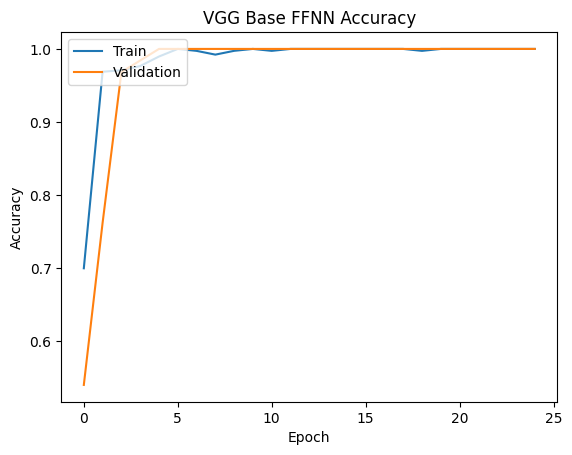

In [ ]:
plt.plot(history_4.history['accuracy'])
plt.plot(history_4.history['val_accuracy'])
plt.title('VGG Base FFNN Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_vgg_base_ffnn_train_perf = model_performance_classification(model_vgg_base_ffnn,X_train_normalized,y_train)

print("Train performance metrics")
print(model_vgg_base_ffnn_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 192ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step


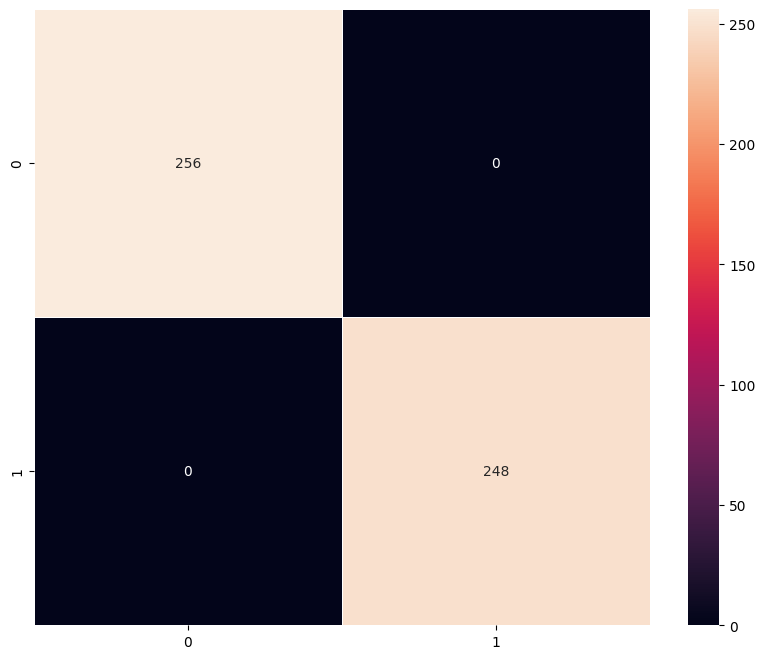

In [ ]:
plot_confusion_matrix(model_vgg_base_ffnn,X_train_normalized,y_train)

In [ ]:
model_vgg_base_ffnn_valid_perf = model_performance_classification(model_vgg_base_ffnn, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_vgg_base_ffnn_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


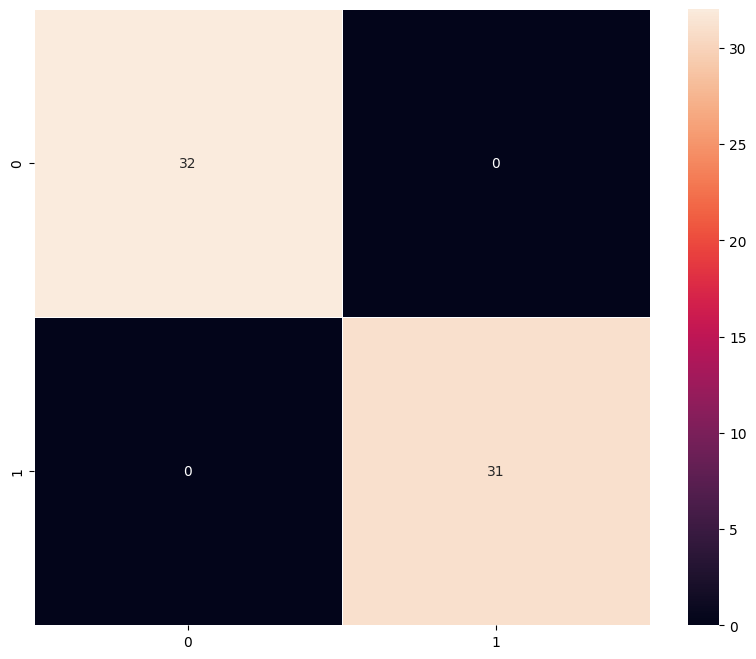

In [ ]:
plot_confusion_matrix(model_vgg_base_ffnn,X_val_normalized,y_val)

#### Visualizing the predictions

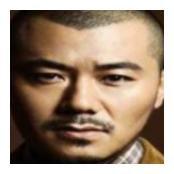

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 602ms/step
Predicted Label: Without Helmet
True Label: Without Helmet


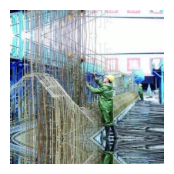

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted Label: With Helmet
True Label: With Helmet


In [ ]:
# For index 12
predict_and_show(12, model_vgg_base_ffnn, X_val, X_val_normalized, y_val)

# For index 33
predict_and_show(33, model_vgg_base_ffnn, X_val, X_val_normalized, y_val)

In [ ]:
# Extract from history objects
metrics_vgg_base_ffnn = extract_metrics(history_4)

# Construct DataFrame
comparison_df = pd.DataFrame({
    'Metric': metrics_cnn.keys(),
    'CNN': metrics_cnn.values(),
    'CNN_DOES': metrics_cnn_does.values(),
    'VGG_Base': metrics_vgg_base.values(),
    'VGG_Base_FFNN': metrics_vgg_base_ffnn.values()
})

# Display
comparison_df

,Metric,CNN,CNN_DOES,VGG_Base,VGG_Base_FFNN
0,Final Training Accuracy,100.00%,100.00%,100.00%,100.00%
1,Final Validation Accuracy,100.00%,100.00%,100.00%,100.00%
2,Final Training Loss,0.0000,0.0053,0.0006,0.0062
3,Best Validation Loss,0.0000 (at Epoch 30),0.0001 (at Epoch 14),0.0010 (at Epoch 30),0.0001 (at Epoch 20)
4,Overfitting Status,No clear sign of overfitting.,Possible overfitting after epoch 14.,No clear sign of overfitting.,Possible overfitting after epoch 20.
5,Validation Accuracy Stability,Stable,Stable,Stable,Stable


* This model represents a significant step up in complexity from Model 2. By adding multiple Dense, BatchNormalization, and Dropout layers, the model has a much greater capacity to learn intricate patterns from the features provided by the VGG16 base.

* Despite its more complex architecture, Model 3 also achieved a perfect 100% validation accuracy. It solved the problem very quickly (by epoch 5), demonstrating that the features from VGG16 are so effective that even a more complex classifier head can easily master the task.

* The added complexity of the deep FFNN provided no practical benefit. Because the simpler Model 2 already achieved a perfect score, the extra power of Model 3 was redundant. The dataset is simply not difficult enough for this more advanced architecture.

## Model 4: (VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [ ]:
model_vgg_base_ffnn_da = Sequential()

# Adding the convolutional part of the VGG16 model
model_vgg_base_ffnn_da.add(vgg_model)

# Flatten the output from convolutional layers
model_vgg_base_ffnn_da.add(Flatten())

# Feedforward dense layers with Dropout
model_vgg_base_ffnn_da.add(Dense(256, activation='relu'))
model_vgg_base_ffnn_da.add(BatchNormalization())
model_vgg_base_ffnn_da.add(Dropout(0.5))  # Higher dropout for larger layer

model_vgg_base_ffnn_da.add(Dense(128, activation='relu'))
model_vgg_base_ffnn_da.add(BatchNormalization())
model_vgg_base_ffnn_da.add(Dropout(0.3))  # Moderate regularization

model_vgg_base_ffnn_da.add(Dense(64, activation='relu'))
model_vgg_base_ffnn_da.add(BatchNormalization())
model_vgg_base_ffnn_da.add(Dropout(0.3))  # Prevent overfitting on intermediate features

model_vgg_base_ffnn_da.add(Dense(32, activation='relu'))  # Final dense layer (no dropout)

# Output layer
model_vgg_base_ffnn_da.add(Dense(1, activation='sigmoid'))

In [ ]:
opt=Adam(learning_rate=0.001)

#Compile model
model_vgg_base_ffnn_da.compile(optimizer=opt, loss=keras.losses.BinaryCrossentropy(), metrics=['accuracy','precision'])

#Model Summary
model_vgg_base_ffnn_da.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,478,593 (74.30 MB)

 Trainable params: 4,763,009 (18.17 MB)

 Non-trainable params: 14,715,584 (56.14 MB)

In [ ]:
train_datagen = ImageDataGenerator(
                              rotation_range=20,
                              fill_mode='nearest',
                              width_shift_range=0.2,
                              height_shift_range=0.2,
                              shear_range=0.1,
                              zoom_range=0.2,
                              horizontal_flip=True,
                              vertical_flip=True,
                              )

In [ ]:
history_5 = model_vgg_base_ffnn_da.fit(train_datagen.flow(X_train_normalized,y_train,
                                      batch_size=BATCH_SIZE,
                                      seed=RANDOM_SEED,
                                      shuffle=False),
                    epochs=EPOCHS,
                    steps_per_epoch=X_train_normalized.shape[0] // BATCH_SIZE,
                    validation_data=(X_val_normalized,y_val),
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.6071 - loss: 0.6952 - precision: 0.6373 - val_accuracy: 0.6349 - val_loss: 0.6542 - val_precision: 1.0000
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - accuracy: 0.9531 - loss: 0.2147 - precision: 0.9508 - val_accuracy: 0.8413 - val_loss: 0.5588 - val_precision: 1.0000
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.9809 - loss: 0.1606 - precision: 0.9664 - val_accuracy: 1.0000 - val_loss: 0.3354 - val_precision: 1.0000
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 200ms/step - accuracy: 1.0000 - loss: 0.1118 - precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.2859 - val_precision: 1.0000
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9953 - loss: 0.0812 - precision: 1.0000 - val_accuracy: 0.9841 - val_loss: 0.1934 - val_precision: 0.9688
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - accuracy: 0.9922 - loss: 0.0646 - precision: 0.9839 - val_accuracy: 0.9841 - val_loss: 0.1714 - val_precis

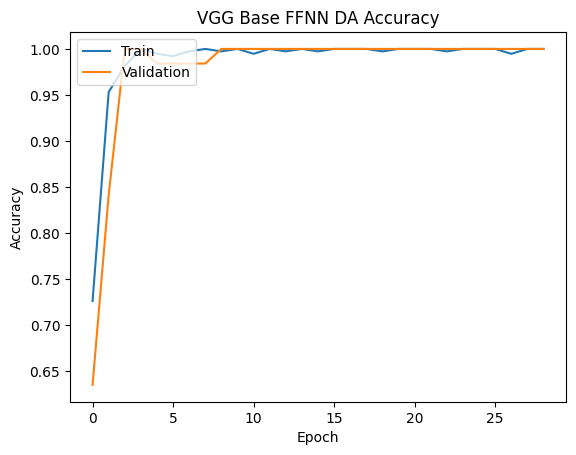

In [ ]:
plt.plot(history_5.history['accuracy'])
plt.plot(history_5.history['val_accuracy'])
plt.title('VGG Base FFNN DA Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model_vgg_base_ffnn_da_train_perf = model_performance_classification(model_vgg_base_ffnn_da,X_train_normalized,y_train)

print("Train performance metrics")
print(model_vgg_base_ffnn_da_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.998016  0.998016   0.998024  0.998016


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step


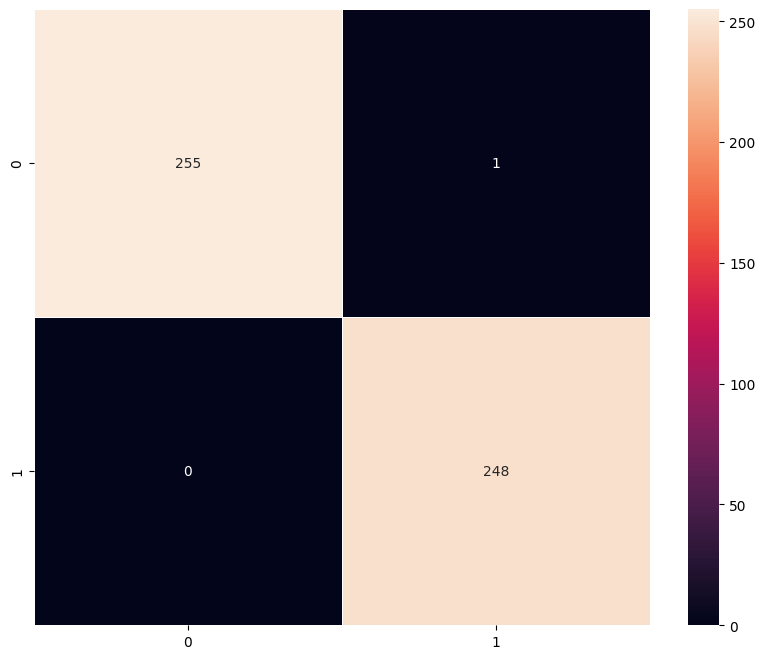

In [ ]:
plot_confusion_matrix(model_vgg_base_ffnn_da,X_train_normalized,y_train)

In [ ]:
model_vgg_base_ffnn_da_valid_perf = model_performance_classification(model_vgg_base_ffnn_da, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_vgg_base_ffnn_da_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 488ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step


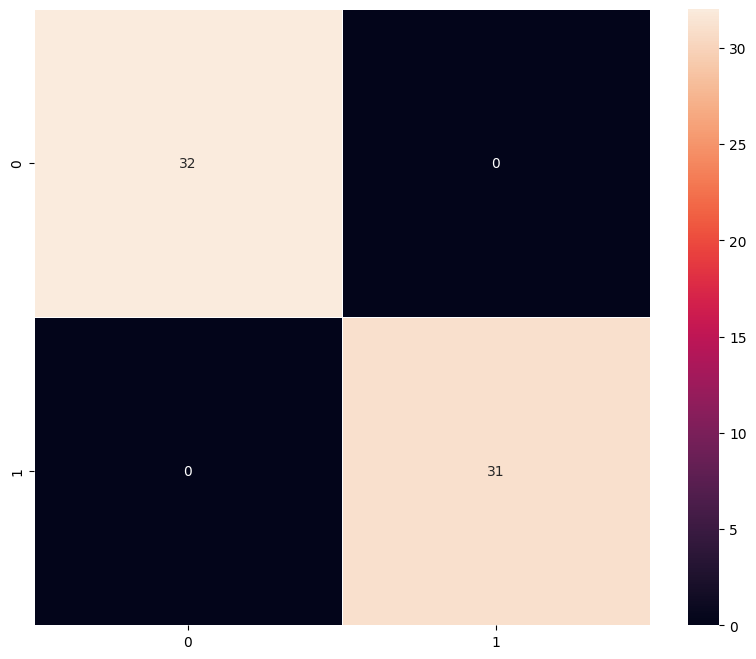

In [ ]:
plot_confusion_matrix(model_vgg_base_ffnn_da,X_val_normalized,y_val)

#### Visualizing the predictions

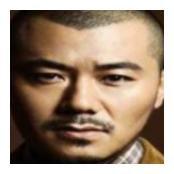

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
Predicted Label: Without Helmet
True Label: Without Helmet


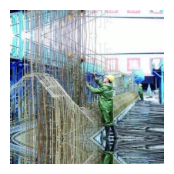

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted Label: With Helmet
True Label: With Helmet


In [ ]:
# For index 12
predict_and_show(12, model_vgg_base_ffnn_da, X_val, X_val_normalized, y_val)

# For index 33
predict_and_show(33, model_vgg_base_ffnn_da, X_val, X_val_normalized, y_val)

In [ ]:
# Extract from history objects
metrics_vgg_base_ffnn_da = extract_metrics(history_5)

# Construct DataFrame
comparison_df = pd.DataFrame({
    'Metric': metrics_cnn.keys(),
    'CNN': metrics_cnn.values(),
    'CNN_DOES': metrics_cnn_does.values(),
    'VGG_Base': metrics_vgg_base.values(),
    'VGG_Base_FFNN': metrics_vgg_base_ffnn.values(),
    'VGG_Base_FFNN_DA': metrics_vgg_base_ffnn_da.values()
})

# Display
comparison_df

,Metric,CNN,CNN_DOES,VGG_Base,VGG_Base_FFNN,VGG_Base_FFNN_DA
0,Final Training Accuracy,100.00%,100.00%,100.00%,100.00%,100.00%
1,Final Validation Accuracy,100.00%,100.00%,100.00%,100.00%,100.00%
2,Final Training Loss,0.0000,0.0053,0.0006,0.0062,0.0040
3,Best Validation Loss,0.0000 (at Epoch 30),0.0001 (at Epoch 14),0.0010 (at Epoch 30),0.0001 (at Epoch 20),0.0061 (at Epoch 24)
4,Overfitting Status,No clear sign of overfitting.,Possible overfitting after epoch 14.,No clear sign of overfitting.,Possible overfitting after epoch 20.,Possible overfitting after epoch 24.
5,Validation Accuracy Stability,Stable,Stable,Stable,Stable,Stable


* This model is the culmination of all the best practices: It combines transfer learning (VGG), a deep classifier head (FFNN), and, most importantly, data augmentation. This is theoretically the best and most robust architecture for preventing overfitting, especially on a small dataset.

* Data augmentation makes the training process harder for the model by showing it varied and "wobbled" images. Despite this, Model 4 still achieved a perfect 100% validation accuracy, and did so very quickly (by epoch 3).

* This is the most critical observation. The model 4 found the validation set trivial - though data augmentation is specifically designed to make the model generalize better and work harder.

* This provides the most definitive evidence that the dataset is not complex or diverse enough to be a meaningful benchmark.

# **Model Performance Comparison and Final Model Selection**

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_cnn_does_train_perf.T,
        model_vgg_base_train_perf.T,
        model_vgg_base_ffnn_train_perf.T,
        model_vgg_base_ffnn_da_train_perf.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "CNN with DOES","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [ ]:
models_valid_comp_df = pd.concat(
    [
        model_cnn_does_valid_perf.T,
        model_vgg_base_valid_perf.T,
        model_vgg_base_ffnn_valid_perf.T,
        model_vgg_base_ffnn_da_valid_perf.T

    ],
    axis=1,
)
models_valid_comp_df.columns = [
 "CNN with DOES","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [ ]:
models_train_comp_df

,CNN with DOES,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,1.0,1.0,1.0,0.998016
Recall,1.0,1.0,1.0,0.998016
Precision,1.0,1.0,1.0,0.998024
F1 Score,1.0,1.0,1.0,0.998016


In [ ]:
models_valid_comp_df

,CNN with DOES,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,1.0,1.0,1.0,1.0
Recall,1.0,1.0,1.0,1.0
Precision,1.0,1.0,1.0,1.0
F1 Score,1.0,1.0,1.0,1.0


In [ ]:
models_train_comp_df - models_valid_comp_df

,CNN with DOES,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.0,0.0,0.0,-0.001984
Recall,0.0,0.0,0.0,-0.001984
Precision,0.0,0.0,0.0,-0.001976
F1 Score,0.0,0.0,0.0,-0.001984


* We will choose the model_vgg_base_ffnn_da for further analysis on test data split.

## Test Performance

In [ ]:
model_vgg_base_ffnn_da_test_perf = model_performance_classification(model_vgg_base_ffnn_da, X_test_normalized,y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step


In [ ]:
model_vgg_base_ffnn_da_test_perf

,Accuracy,Recall,Precision,F1 Score
0,1.0,1.0,1.0,1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


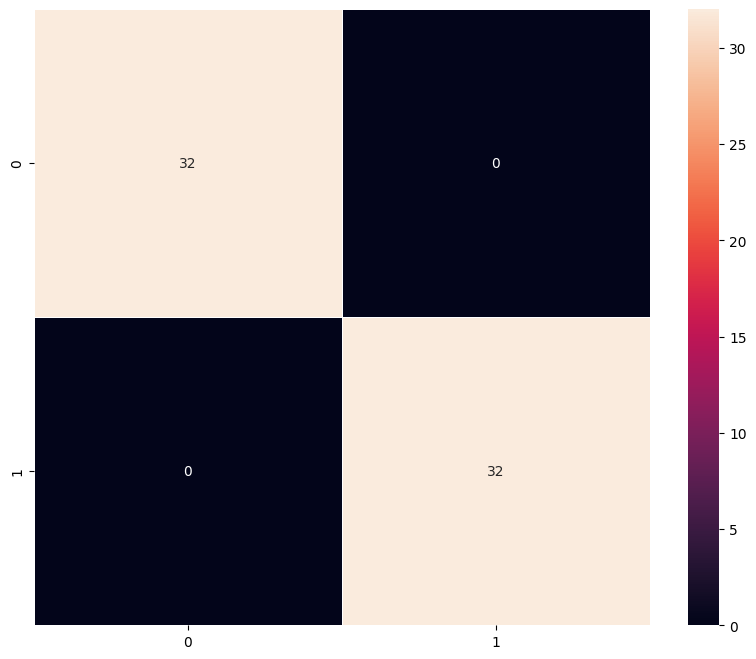

In [ ]:
plot_confusion_matrix(model_vgg_base_ffnn_da, X_test_normalized,y_test)

Showing predictions for 5 random images with indices: [39, 24, 51, 12, 26]


 --- Prediction for image at index: 39 ---


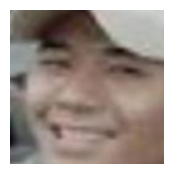

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted Label: Without Helmet
True Label: Without Helmet

 --- Prediction for image at index: 24 ---


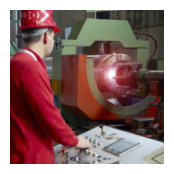

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted Label: With Helmet
True Label: With Helmet

 --- Prediction for image at index: 51 ---


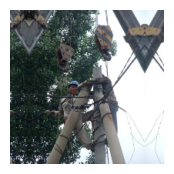

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted Label: With Helmet
True Label: With Helmet

 --- Prediction for image at index: 12 ---


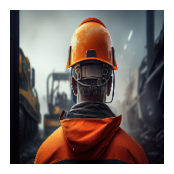

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted Label: With Helmet
True Label: With Helmet

 --- Prediction for image at index: 26 ---


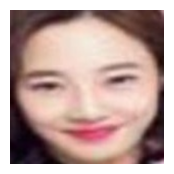

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted Label: Without Helmet
True Label: Without Helmet


In [ ]:
num_images_to_show = 5
random_indicies = random.sample(range(0, len(X_test_normalized)), num_images_to_show)
print(f"Showing predictions for {num_images_to_show} random images with indices: {random_indicies}\n")

for index in random_indicies:
    print(f"\n --- Prediction for image at index: {index} ---")

    # Call your existing function with the current random index
    # Pass the test set data (X_test, X_test_normalized, y_test) instead of validation set data
    predict_and_show(index, model_vgg_base_ffnn_da, X_test, X_test_normalized, y_test)

# **Actionable Insights & Recommendations**

# Actionable Insights
1. All the models performed very well and got 100% accuracy on validation set.
2. The chosen model "Model 4: (VGG-16 (Base + FFNN + Data Augmentation)" achieved 100% accuracy on the test set.
3. This score is very deceptive and probably is an artifact of the dataset.
4. These models are not challenged significantly and should not be deployed in the real world.
5. The dataset is too small and probably needs more variety. My suspicion is that the training, validation and test splits are too similar to each other.
6. These observations aside, the best model would be the "VGA 16 Base with FFNN and Data Augmentation" due to its demonstrated robustness.

# Recommendations
1. The next step of focus should be data curation - build a more robust and realistic dataset
2. Expand the dataset - maybe create an archive of 5000 - 10,000 images.
3. Prioritize data diversity - different environments, conditions, helmet types etc.
4. Once the "new" dataset is ready, train the "VGA 16 Base with FFNN and Data Augmentation" for more realistic performance metrics and revealing flaws in the model.

<font size=5 color='blue'>Power Ahead!</font>
___